1. Importación de paquetes:

In [150]:
import pandas as pd 
import ast
import numpy as np

2. Leectura de csv:

Filas y columnas iniciales: (25000, 79)
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object
calendar_updated               25000
host_neighbourhood             17078
license                        15812
neighborhood_overview          14414
neighbourhood                  14414
host_about                     12402
host_location                   8150
price                           6047
estimated_revenue_l365

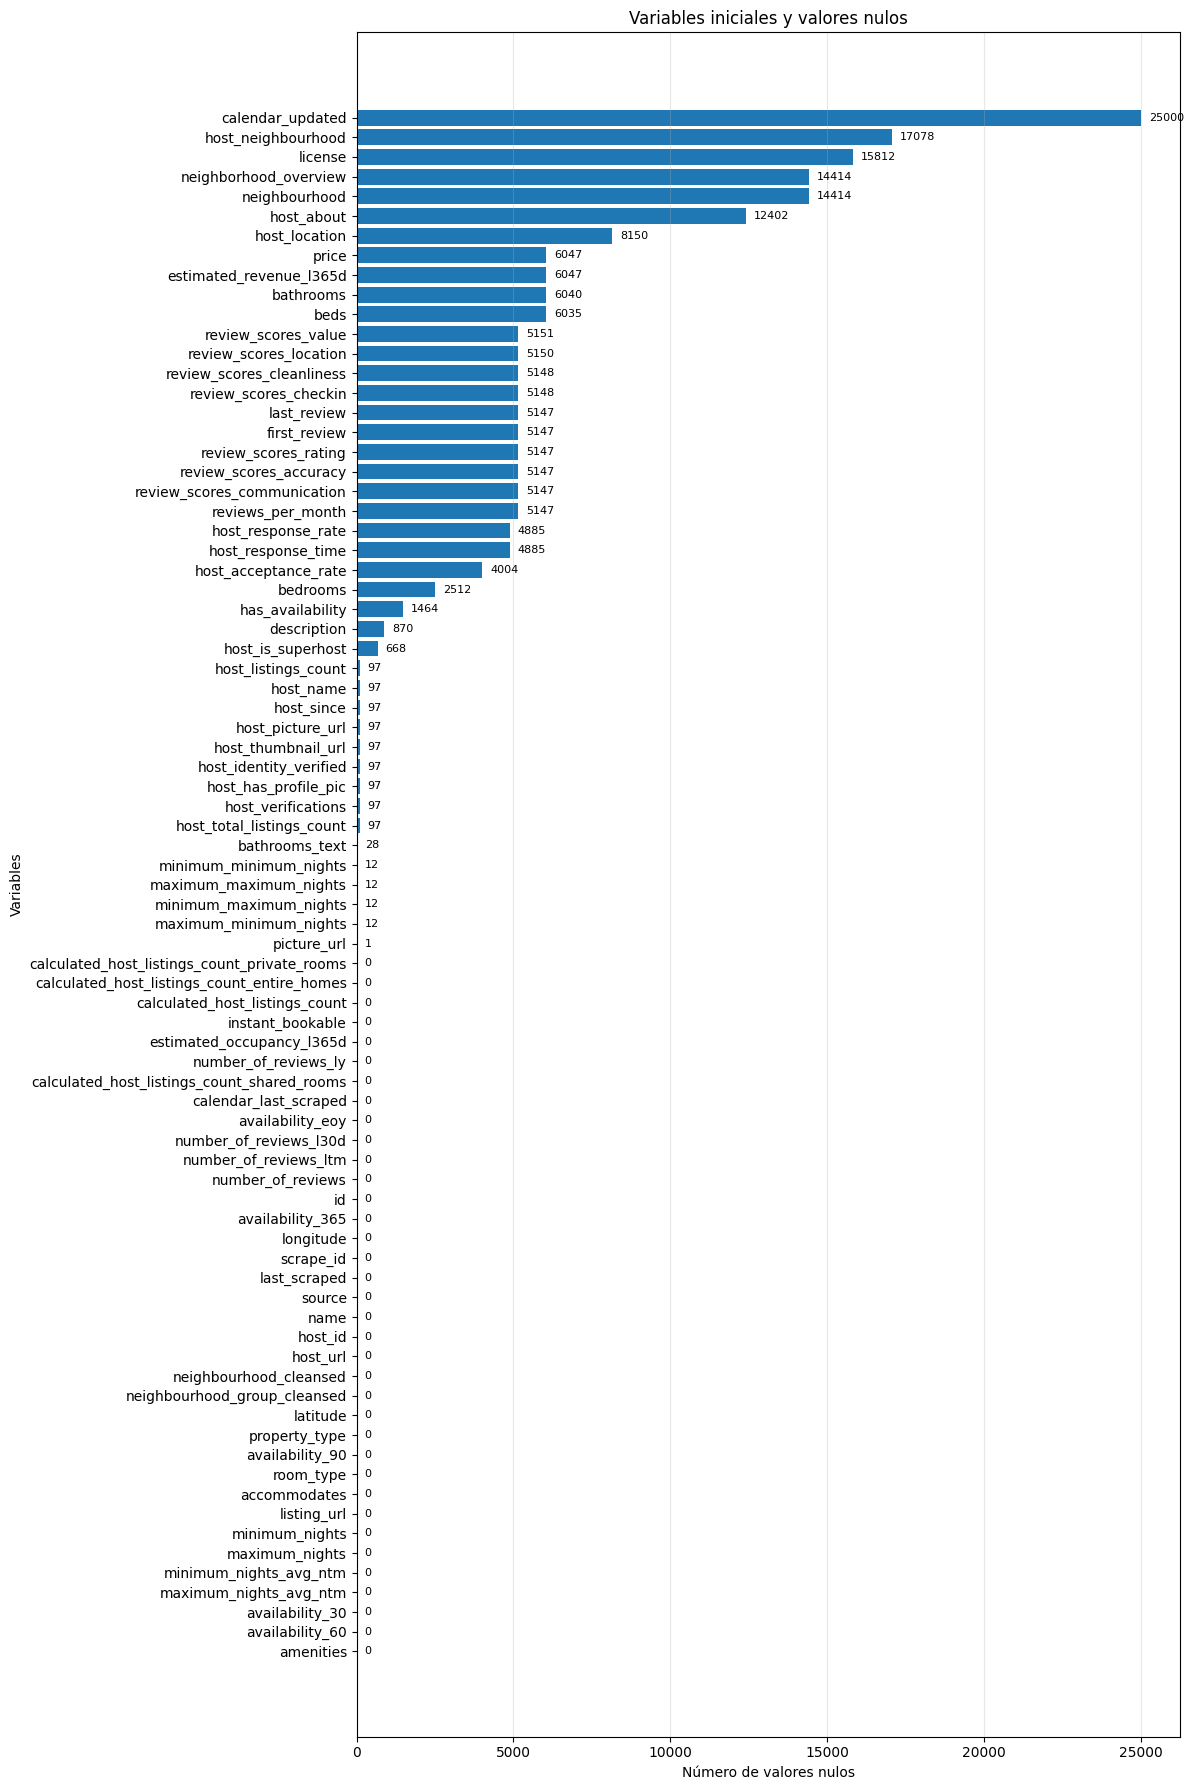

In [151]:
#2.1 CARGA DEL CSV:
listings = pd.read_csv('/Users/luciagonzalezdavila/Documents/4º/TFG/BBDD airbnb/listings.csv')

#2.2 EXPLORACIÓN INICIAL: 
#2.2.1Filas y columnas: 
print("Filas y columnas iniciales:", listings.shape)

#2.2.2Tipos de variables: 
print(listings.dtypes)

#2.2.3Exploración de las variables numéricas: 
listings.describe()

#2.2.4Nulos:
print(listings.isnull().sum().sort_values(ascending=False).head(20))

#2.2.5 VISUALIZACIÓN DE LAS VARIABLES INICIALES Y VALORES NULOS:
null_counts = listings.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(12,18))
bars = plt.barh(null_counts.index[::-1], null_counts.values[::-1])
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(null_counts) * 0.01,         
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=8
    )
plt.xlabel("Número de valores nulos")
plt.ylabel("Variables")
plt.title("Variables iniciales y valores nulos")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



In [152]:
#Ver NaN y string vacias (¿coinciden con null?)
Total_blanco_null_NaN= listings.isnull().sum() + (listings == "").sum()
Total_blanco_null_NaN = Total_blanco_null_NaN[Total_blanco_null_NaN > 0].sort_values(ascending=False)
print(Total_blanco_null_NaN)

calendar_updated               25000
host_neighbourhood             17078
license                        15812
neighborhood_overview          14414
neighbourhood                  14414
host_about                     12402
host_location                   8150
price                           6047
estimated_revenue_l365d         6047
bathrooms                       6040
beds                            6035
review_scores_value             5151
review_scores_location          5150
review_scores_checkin           5148
review_scores_cleanliness       5148
first_review                    5147
reviews_per_month               5147
last_review                     5147
review_scores_rating            5147
review_scores_accuracy          5147
review_scores_communication     5147
host_response_rate              4885
host_response_time              4885
host_acceptance_rate            4004
bedrooms                        2512
has_availability                1464
description                      870
h

3. Diseño de las columnas: 

In [153]:
#3.1 VISUALIZACIÓN DE COLUMNAS:
cols = [
    "id",
    "host_id",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "price",
    "minimum_nights",
    "maximum_nights",
    "latitude",
    "longitude",
    "neighbourhood_cleansed",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "reviews_per_month",
    "host_since",
    "host_is_superhost",
    "instant_bookable",
    "amenities",
    "calculated_host_listings_count",
    "availability_365",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]


print(listings.columns.tolist())
print(len(listings.columns))

#3.2 REORGANIZACIÓN: 
#Filtrar columnas para que solo se quede con las que he mencionado: 
listings = listings[cols]
#Renombrar columnas: 
listings = listings.rename(columns={"id": "listing_id"})

#Limpieza en precio: 
listings["price"] = listings["price"].replace(r"[\$,]", "", regex=True).astype(float)

#Limpieza en baños: 
#a)Convertir a nuemrico y si es raro en missing:
listings["bathrooms"] = pd.to_numeric(listings["bathrooms"], errors="coerce")
#b)Ver si faltaban datos:
listings["bathrooms_missing"] = listings["bathrooms"].isna().astype(int)
#c)Rellenar los valores faltanntes con 0 y usar la mediana (evita outliers, no distorsiona)
listings["bathrooms"] = listings["bathrooms"].fillna(listings["bathrooms"].median())


#Limpieza en anfitrión (binaria): 
listings["host_is_superhost"] = listings["host_is_superhost"].map({"t":1, "f":0}).fillna(0)

#Limpieza en booking(binaria): 
listings["instant_bookable"] = listings["instant_bookable"].map({"t":1, "f":0}).fillna(0)

#Limpieza en amenities (de semiestructutrado a variables cuantitativas): 
#a)Creación de una función que devuelve una lista vacia si no hay datos y convierte las string en listas reales sin errores:
def parse_amenities(x):
    if pd.isna(x) or x == "":
        return []
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except:
        return []
#b)Aplicamos la función [conivierte la columna en listas realies]:
listings["amenities_list"] = listings["amenities"].apply(parse_amenities)
#c)Cuenta correctamente el número real:
listings["amenities_count"] = listings["amenities_list"].apply(len)
#d)Ver si tiene wifi:
listings["has_wifi"] = listings["amenities_list"].apply(lambda x: int("Wifi" in x))


#Limpieza en fecha alojamiento: 
listings["host_since"] = pd.to_datetime(listings["host_since"], errors="coerce")
#Fecha fija para que sea reproducible:
reference_date = pd.Timestamp("2025-12-01")
listings["host_tenure_days"] =  (reference_date - listings["host_since"]).dt.days


['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [154]:
#3.3 CREACIÓN DE NUEVAS COLUMNAS:
#RevPAR
listings["revpar"] = listings["estimated_revenue_l365d"] / 365
#Ocupación:
listings["occupancy_rate"] = listings["estimated_occupancy_l365d"] / 365


#ADR (APX, solo chequeo):
listings["adr_check"] = listings["estimated_revenue_l365d"] / listings["estimated_occupancy_l365d"].replace(0, np.nan)
#Otras variables (derivativas): 
# Precio por persona (evitando división entre 0):
listings["accommodates"] = listings["accommodates"].replace(0, 1)
listings["price_per_person"] = listings["price"] / listings["accommodates"]
# Host profesional (considero profesional si tiene más de un alojamiento):
listings["professional_host"] = (listings["calculated_host_listings_count"] > 1).astype(int)


4. Limpieza: 

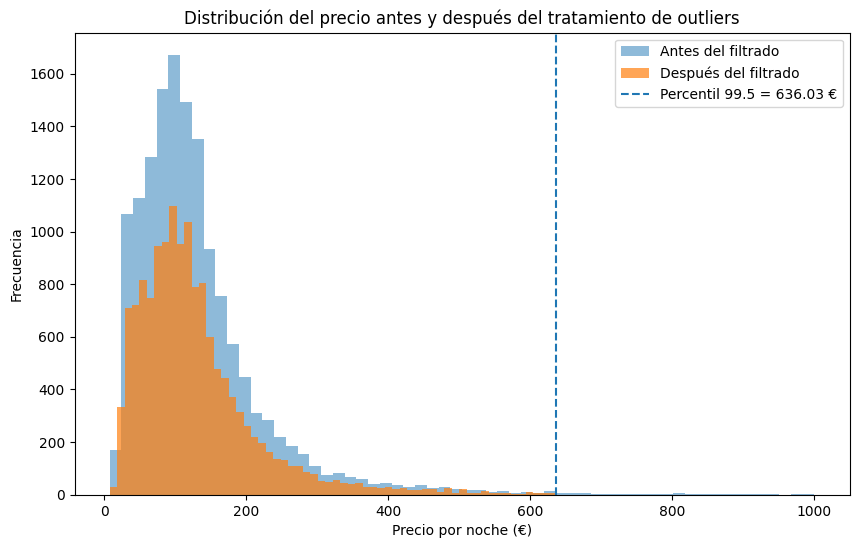

Valores nulos tras la limpieza:
host_since          88
host_tenure_days    88
bedrooms            23
beds                 9
dtype: int64


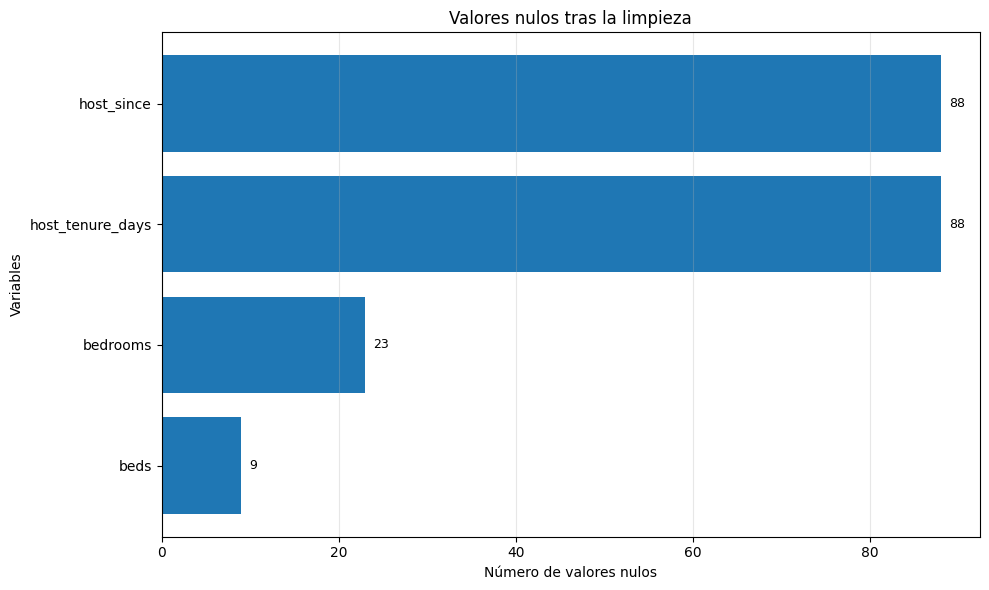

In [155]:

#eliminacion de outliers de precio (el 0,5% mñas extremo, eliminando el subjetivismo de lo considerado "caro" y "barato"):
upper_price = listings["price"].quantile(0.995)
listings = listings[listings["price"] <= upper_price]

# Eliminación de casos sin beneficio o sin ocupación (así me quedo solo con los activos):
listings = listings[
    (listings["estimated_occupancy_l365d"] > 0) &
    (listings["estimated_revenue_l365d"] > 0)
]

#Grafico de outliers:
#Carga del paquete de visualización:
import matplotlib.pyplot as plt
#Guardar una copia antes del filtrado: 
listings_pre_filtrado = listings.copy()
#Umbral percentil 99.5:
upper_price = listings_pre_filtrado["price"].quantile(0.995)
#Aplicar filtro:
listings_post_filtrado = listings_pre_filtrado[listings_pre_filtrado["price"] <= upper_price].copy()
#Visualización:
plt.figure(figsize=(10,6))
plt.hist(listings_pre_filtrado["price"].dropna(), bins=60, alpha=0.5, label="Antes del filtrado")
plt.hist(listings_post_filtrado["price"].dropna(), bins=60, alpha=0.7, label="Después del filtrado")
plt.axvline(upper_price, linestyle="--", label=f"Percentil 99.5 = {upper_price:.2f} €")
plt.title("Distribución del precio antes y después del tratamiento de outliers")
plt.xlabel("Precio por noche (€)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


#Gráfico de nulos tras limpieza: 
#1ºcomporbar nulos: 
null_counts_final = listings.isnull().sum()
null_counts_final = null_counts_final[null_counts_final > 0].sort_values(ascending=False)
print("Valores nulos tras la limpieza:")
print(null_counts_final)

#2ºVisualización: 
if len(null_counts_final) > 0:
    plt.figure(figsize=(10,6))
    bars = plt.barh(null_counts_final.index[::-1], null_counts_final.values[::-1])
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + max(null_counts_final) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}",
            va="center",
            fontsize=9
        )
    plt.xlabel("Número de valores nulos")
    plt.ylabel("Variables")
    plt.title("Valores nulos tras la limpieza")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No quedan valores nulos en el dataset final.")


5. Comprobaciones: 

       estimated_occupancy_l365d  occupancy_rate  estimated_revenue_l365d  \
count               14398.000000    14398.000000             14398.000000   
mean                  132.595986        0.363277             17059.262050   
std                    93.817391        0.257034             18636.423884   
min                     6.000000        0.016438                48.000000   
25%                    42.000000        0.115068              4080.000000   
50%                   120.000000        0.328767             11475.000000   
75%                   252.000000        0.690411             24225.000000   
max                   255.000000        0.698630            254490.000000   

          adr_check        revpar  
count  14398.000000  14398.000000  
mean     132.815252     46.737704  
std       98.458478     51.058696  
min        8.000000      0.131507  
25%       74.000000     11.178082  
50%      111.000000     31.438356  
75%      160.000000     66.369863  
max     1000.00000

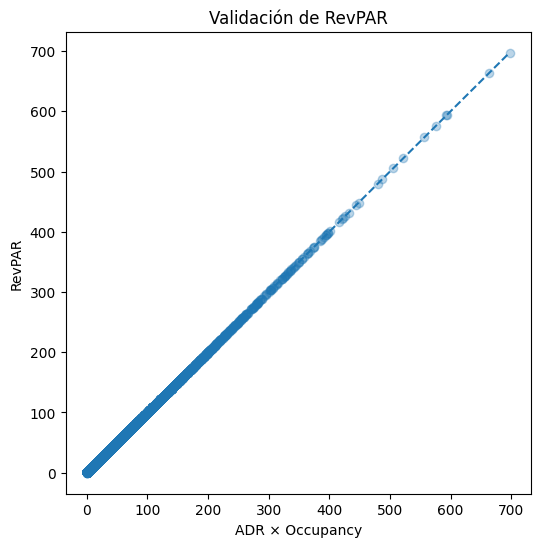

In [156]:
#Estadísticos de las variables: 
print(listings[["estimated_occupancy_l365d",
                "occupancy_rate",
                "estimated_revenue_l365d",
                "adr_check",
                "revpar"]].describe())

#Calculo de RevPAR para vericar que sea coherente (RevPAR = ADR * Occupancy Rate):
check = listings["adr_check"] * listings["occupancy_rate"]

#Tabla de comparación (RevPAR calculado vs RevPAR "recontruido"):
comparison = pd.DataFrame({
    "revpar": pd.to_numeric(listings["revpar"], errors="coerce"),
    "adr_x_occ": pd.to_numeric(check, errors="coerce")
})
print(comparison.head(10))

#Ver la diferencia entre ambos cálculos:
diff = comparison["revpar"] - comparison["adr_x_occ"]
diff = pd.to_numeric(diff, errors="coerce")
print(diff.describe())
print("Máxima diferencia absoluta:", diff.abs().max())
print(comparison.head(10))
print((comparison["revpar"] - comparison["adr_x_occ"]).describe())

#Visualización: 
plt.figure(figsize=(6,6))
plt.scatter(comparison["adr_x_occ"], comparison["revpar"], alpha=0.3)
plt.xlabel("ADR × Occupancy")
plt.ylabel("RevPAR")
plt.title("Validación de RevPAR")
plt.plot([0, comparison["revpar"].max()],
         [0, comparison["revpar"].max()],
         linestyle="--")
plt.show()

6. Output:

In [157]:
#Output: 
listings.to_csv('/Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/listings_clean.csv', index=False)

7. Visualización:

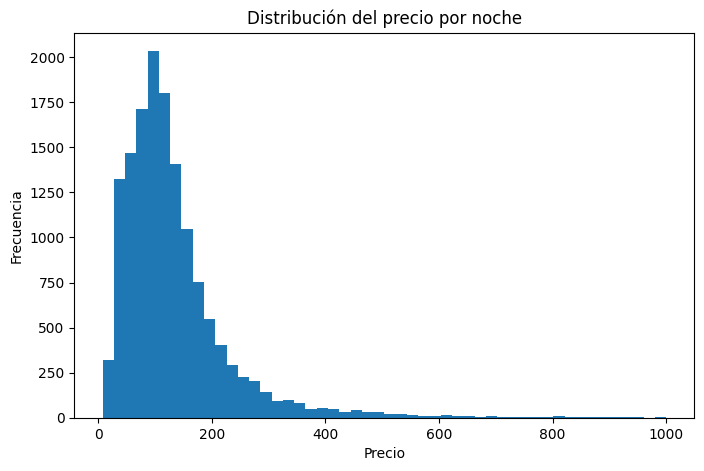

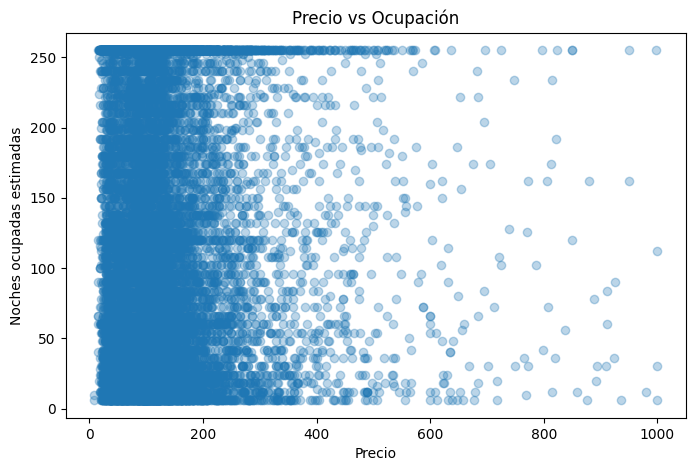

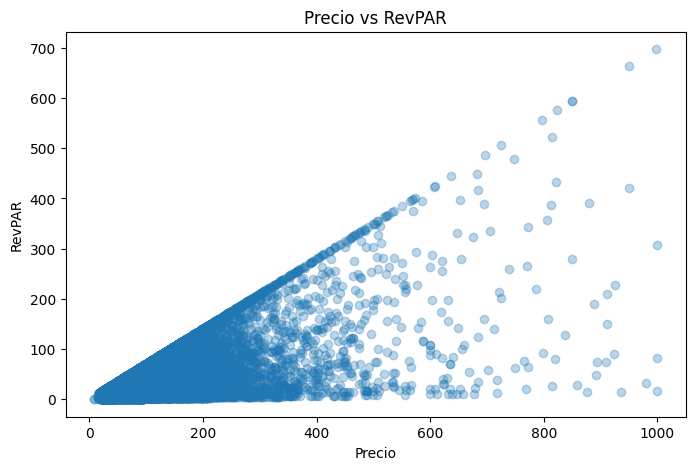

/var/folders/my/sdg31b0x4dvbgllqt75_yz_80000gn/T/ipykernel_79812/4203524054.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(room_data, labels=labels)


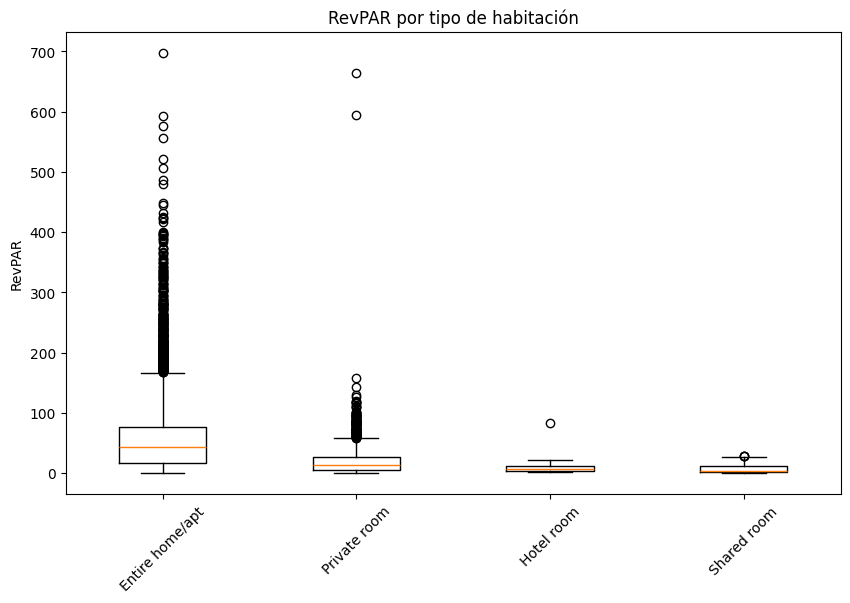

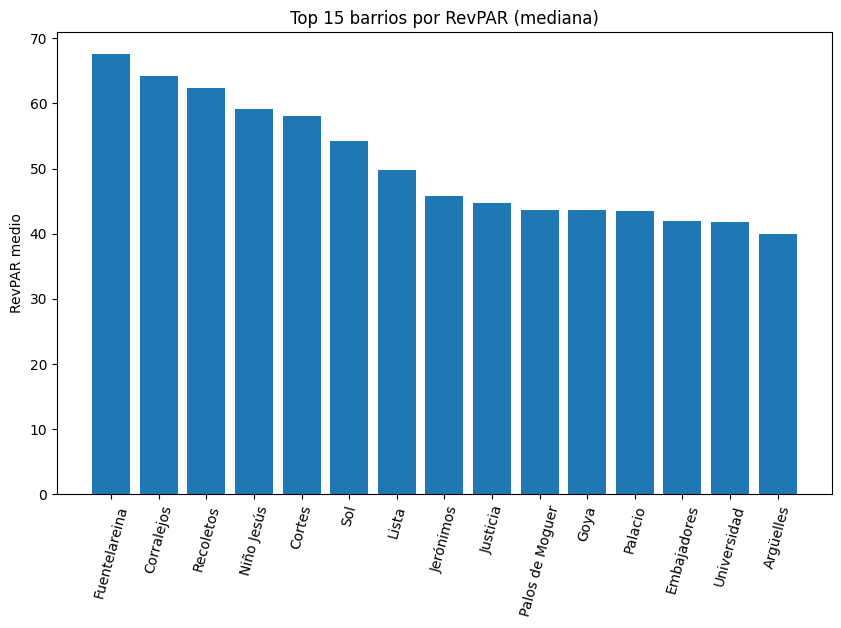

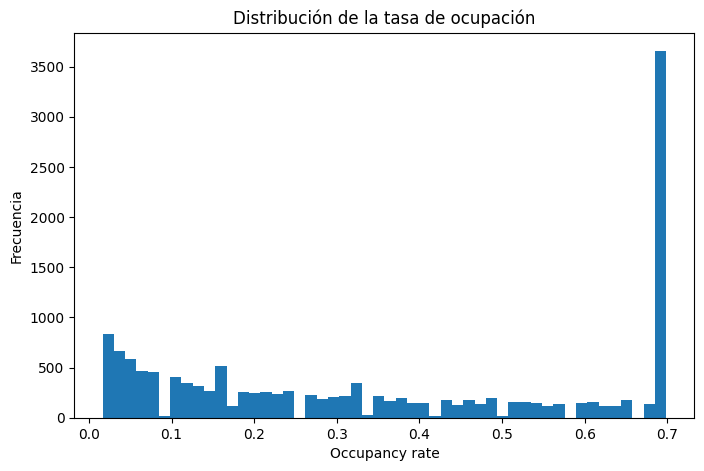

Precio medio:
host_is_superhost
0.0    131.749522
1.0    135.186114
Name: price, dtype: float64
Ocupación media:
host_is_superhost
0.0    115.032619
1.0    171.668085
Name: estimated_occupancy_l365d, dtype: float64
RevPAR medio:
professional_host
0    47.171052
1    46.599997
Name: revpar, dtype: float64
Precio medio:
professional_host
0    117.429147
1    137.704558
Name: price, dtype: float64
Ocupación media:
professional_host
0    147.163594
1    127.966776
Name: estimated_occupancy_l365d, dtype: float64
                              price  accommodates  bedrooms  \
price                      1.000000      0.604596  0.510488   
accommodates               0.604596      1.000000  0.684021   
bedrooms                   0.510488      0.684021  1.000000   
review_scores_rating       0.043478     -0.012143  0.019225   
estimated_occupancy_l365d -0.059710      0.030444  0.015263   
revpar                     0.582689      0.447123  0.385430   

                           review_scores_rati

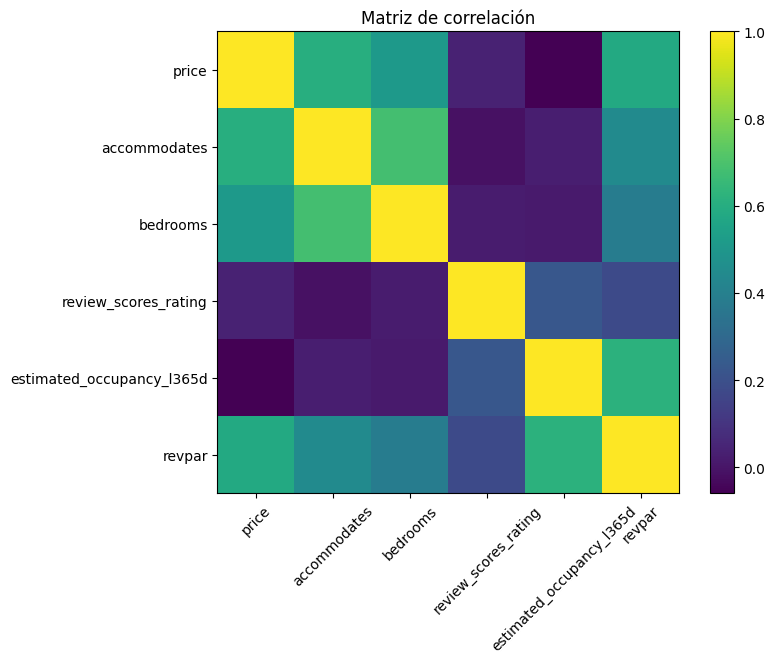

In [158]:
#7.2 DISTRIBUCIÓN DE PRECIOS:
plt.figure(figsize=(8,5))
plt.hist(listings["price"].dropna(), bins=50)
plt.title("Distribución del precio por noche")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

#7.3 PRECIO VS OCUPACIÓN: 
plt.figure(figsize=(8,5))
plt.scatter(listings["price"], listings["estimated_occupancy_l365d"], alpha=0.3)
plt.title("Precio vs Ocupación")
plt.xlabel("Precio")
plt.ylabel("Noches ocupadas estimadas")
plt.show()

#7.4 PRECIO VS REVPAR:
plt.figure(figsize=(8,5))
plt.scatter(listings["price"], listings["revpar"], alpha=0.3)
plt.title("Precio vs RevPAR")
plt.xlabel("Precio")
plt.ylabel("RevPAR")
plt.show()

#7.5 BOXPLOT POR TIPO DE HABITACIÓN: 
room_data = []
labels = []

for room_type in listings["room_type"].dropna().unique():
    room_data.append(listings[listings["room_type"] == room_type]["revpar"].dropna())
    labels.append(room_type)

plt.figure(figsize=(10,6))
plt.boxplot(room_data, labels=labels)
plt.title("RevPAR por tipo de habitación")
plt.ylabel("RevPAR")
plt.xticks(rotation=45)
plt.show()


#7.6 REVPAR MEDIO POR BARRIO: IGUAL ES MEJOR CAMBIARLO POR MEDIANA?, INVESTIGAR
revpar_barrio = listings.groupby("neighbourhood_cleansed")["revpar"].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.bar(revpar_barrio.index, revpar_barrio.values)
plt.title("Top 15 barrios por RevPAR (mediana)")
plt.ylabel("RevPAR medio")
plt.xticks(rotation=75)
plt.show()


#7.7 DISTRIBUCIÓN TASA DE OCUPACIÓN:
plt.figure(figsize=(8,5))
plt.hist(listings["occupancy_rate"].dropna(), bins=50)
plt.title("Distribución de la tasa de ocupación")
plt.xlabel("Occupancy rate")
plt.ylabel("Frecuencia")
plt.show()

#Creación variable SUPERHOST: 
listings.groupby("host_is_superhost")["revpar"].mean()

#7.8 SUPERHOST:
print("Precio medio:")
print(listings.groupby("host_is_superhost")["price"].mean())

print("Ocupación media:")
print(listings.groupby("host_is_superhost")["estimated_occupancy_l365d"].mean())


#7.9 PROFESIONAL
print("RevPAR medio:")
print(listings.groupby("professional_host")["revpar"].mean())

print("Precio medio:")
print(listings.groupby("professional_host")["price"].mean())

print("Ocupación media:")
print(listings.groupby("professional_host")["estimated_occupancy_l365d"].mean())

#7.9 CORRELACIÓN: 
corr = listings[[
    "price",
    "accommodates",
    "bedrooms",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "revpar"
]].corr()
print(corr)

#De forma visual: 
plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.show()

8. Modelado:

In [159]:
#8.1 PREPARACIONES PREVIAS:
# Copia del dataset:
listings = listings.copy()

#Revisar nulos: 
print(listings[[
    "price", "accommodates", "bedrooms", "amenities_count", "has_wifi",
    "room_type", "neighbourhood_cleansed", "review_scores_rating", "host_is_superhost"
]].isna().sum())

#Eliminar los nulos: 
model_data_price = listings[[
    "price", "accommodates", "bedrooms", "amenities_count", "has_wifi",
    "room_type", "neighbourhood_cleansed", "review_scores_rating", "host_is_superhost"
]].dropna().copy()


price                      0
accommodates               0
bedrooms                  23
amenities_count            0
has_wifi                   0
room_type                  0
neighbourhood_cleansed     0
review_scores_rating       0
host_is_superhost          0
dtype: int64


RMSE precio: 69.88800479637358
MAE precio: 42.57991088406634
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.491
Method:                 Least Squares   F-statistic:                     104.6
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:53:13   Log-Likelihood:                -81446.
No. Observations:               14375   AIC:                         1.632e+05
Df Residuals:                   14240   BIC:                         1.642e+05
Df Model:                         134                                         
Covariance Type:            nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

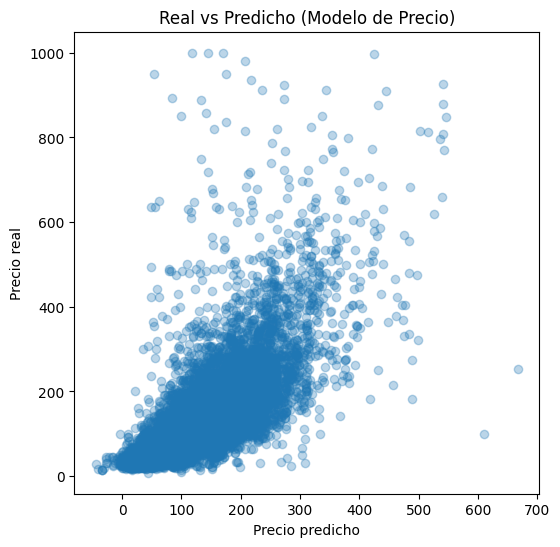

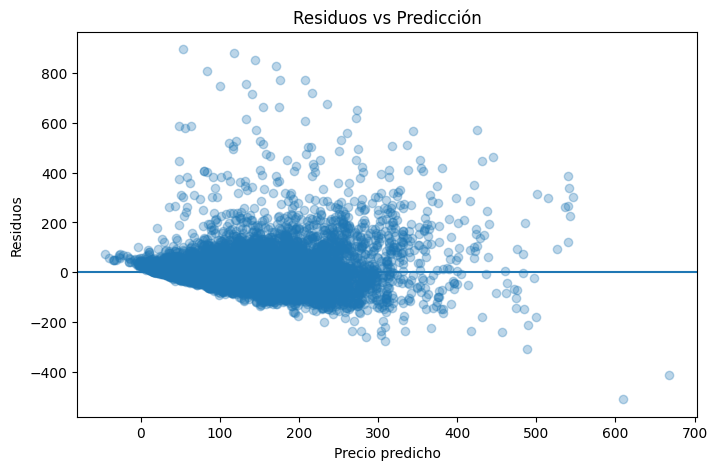

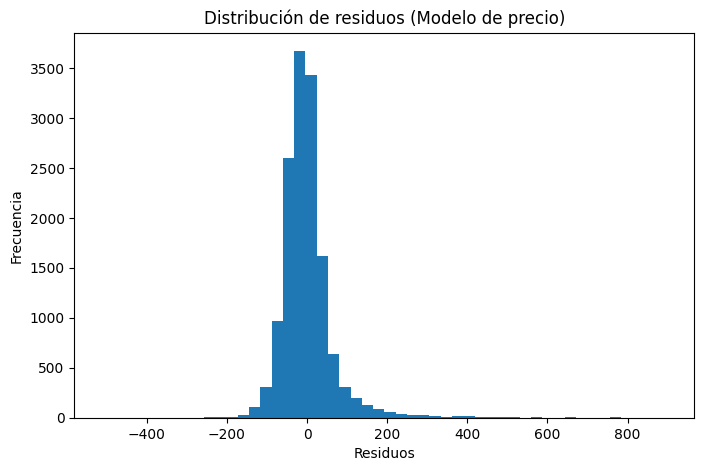

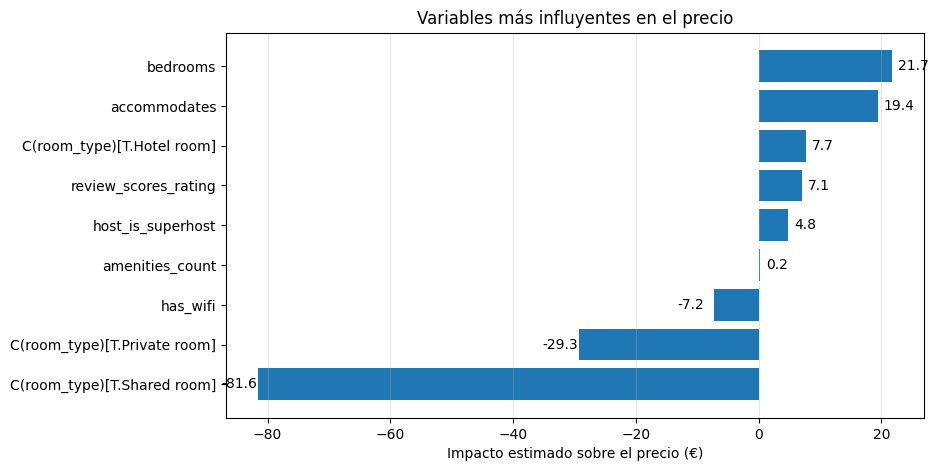

In [160]:

#8.2 MODELO 1 — PRECIO (HEDONIC PRICING)
#Instalación de paquete necesario:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
#Creación del modelo:
model_price = smf.ols(
    formula="""
    price ~ accommodates + bedrooms + amenities_count + has_wifi + C(room_type) + 
            C(neighbourhood_cleansed) + 
            review_scores_rating + host_is_superhost
    """,
    data=model_data_price
).fit()

#Métricas:
y_true_price = model_data_price["price"]
y_pred_price = model_price.fittedvalues

rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mae_price = mean_absolute_error(y_true_price, y_pred_price)

print("RMSE precio:", rmse_price)
print("MAE precio:", mae_price)

print(model_price.summary())

#Visualización gráfica del modelo:
#Gráfico real vs predicho:
pred = model_price.fittedvalues
real = listings.loc[pred.index, "price"]

plt.figure(figsize=(6,6))
plt.scatter(pred, real, alpha=0.3)
plt.xlabel("Precio predicho")
plt.ylabel("Precio real")
plt.title("Real vs Predicho (Modelo de Precio)")
plt.show()

#Gráfico de residuos:
residuals = y_true_price - y_pred_price
plt.figure(figsize=(8,5))
plt.scatter(y_pred_price, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Precio predicho")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicción")
plt.show()

#Distribución de residuos: 
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Distribución de residuos (Modelo de precio)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

# Importancia aproximada de variables:
coefs = model_price.params.copy()
# Filtrado de variables principales:
variables_clave = [
    "accommodates",
    "bedrooms",
    "amenities_count",
    "has_wifi",
    "review_scores_rating",
    "host_is_superhost",
    "C(room_type)[T.Private room]",
    "C(room_type)[T.Shared room]",
    "C(room_type)[T.Hotel room]"
]
coefs_filtrados = coefs[coefs.index.isin(variables_clave)].sort_values()
plt.figure(figsize=(9, 5))
bars = plt.barh(coefs_filtrados.index, coefs_filtrados.values)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (1 if width >= 0 else -6),    
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center"
    )
plt.xlabel("Impacto estimado sobre el precio (€)")
plt.title("Variables más influyentes en el precio")
plt.grid(axis="x", alpha=0.3)
plt.show()

occupancy_rate             0
log_price                  0
accommodates               0
bedrooms                  23
amenities_count            0
has_wifi                   0
bathrooms_missing          0
room_type                  0
neighbourhood_cleansed     0
review_scores_rating       0
host_is_superhost          0
dtype: int64
RMSE ocupación: 0.22690951752636881
MAE ocupación: 0.19575144309211862
                            OLS Regression Results                            
Dep. Variable:         occupancy_rate   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     29.59
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:53:14   Log-Likelihood:                 923.82
No. Observations:               14375   AIC:                            -1574.
Df Residuals:                   14238   BIC:

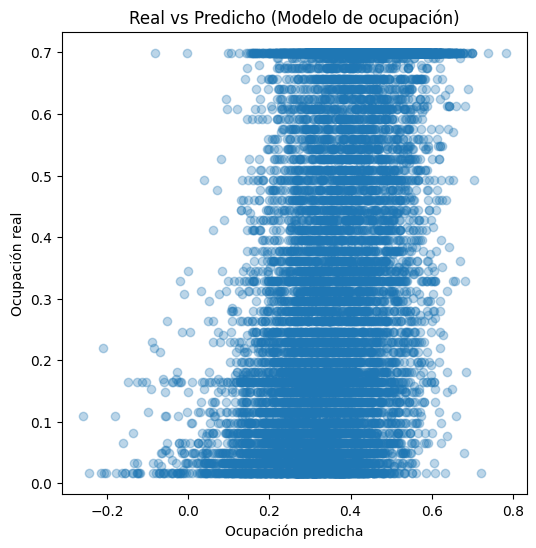

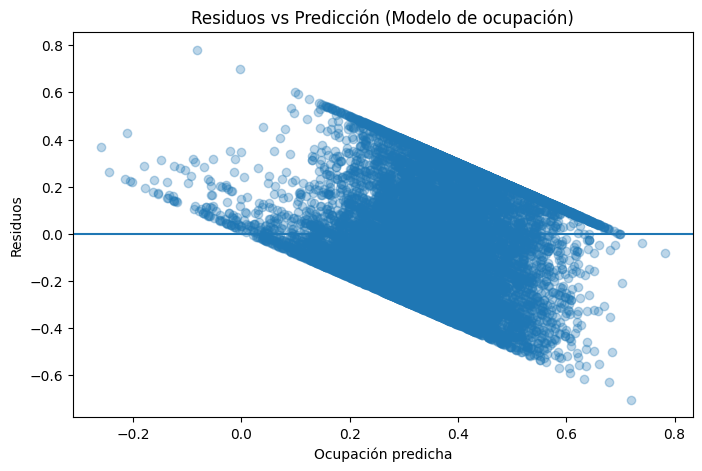

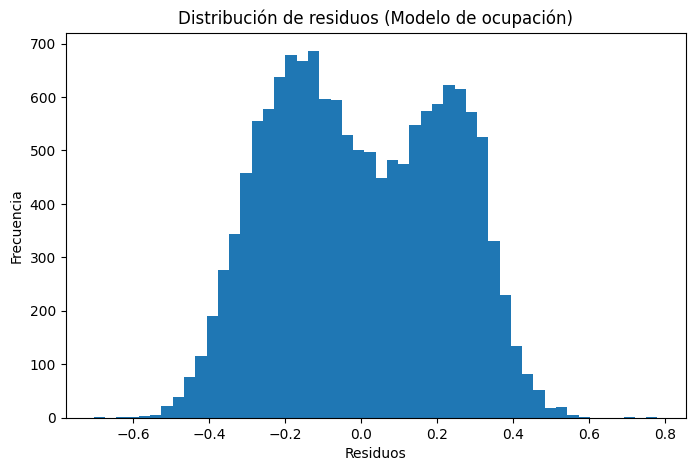

In [161]:
#8.3 MODELO 2 — OCUPACIÓN (LOG PRECIO): 
#Evitar problemas con log(0) y hacer una copia:
occ_data = listings[listings["price"] > 0].copy()

#Creación de variable para poder observar las subidas porcentuales: 
occ_data["log_price"] = np.log(occ_data["price"])

#Revisar los nulos en la ocupación: 
print(occ_data[[
    "occupancy_rate", "log_price", "accommodates", "bedrooms",
    "amenities_count", "has_wifi", "bathrooms_missing",
    "room_type", "neighbourhood_cleansed",
    "review_scores_rating", "host_is_superhost"
]].isna().sum())

#Crear base específica para el modelo de ocupación:
model_data_occ = occ_data[[
    "occupancy_rate", "log_price", "accommodates", "bedrooms",
    "amenities_count", "has_wifi", "bathrooms_missing",
    "room_type", "neighbourhood_cleansed",
    "review_scores_rating", "host_is_superhost"
]].dropna().copy()

#Modelo:
model_occ = smf.ols(
    formula="""
    occupancy_rate ~ log_price + accommodates + bedrooms + amenities_count + has_wifi + bathrooms_missing +
                     C(room_type) + C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data=model_data_occ
).fit()


#Métricas:
y_true_occ = model_data_occ["occupancy_rate"]
y_pred_occ = model_occ.fittedvalues

rmse_occ = np.sqrt(mean_squared_error(y_true_occ, y_pred_occ))
mae_occ = mean_absolute_error(y_true_occ, y_pred_occ)

print("RMSE ocupación:", rmse_occ)
print("MAE ocupación:", mae_occ)

print(model_occ.summary())

#Visualización gráfica del modelo:
#Gráfico real vs predicho:
plt.figure(figsize=(6,6))
plt.scatter(y_pred_occ, y_true_occ, alpha=0.3)
plt.xlabel("Ocupación predicha")
plt.ylabel("Ocupación real")
plt.title("Real vs Predicho (Modelo de ocupación)")
plt.show()

#Residuos y predicción: 
residuals_occ = y_true_occ - y_pred_occ
plt.figure(figsize=(8,5))
plt.scatter(y_pred_occ, residuals_occ, alpha=0.3)
plt.axhline(0)
plt.xlabel("Ocupación predicha")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicción (Modelo de ocupación)")
plt.show()

#Distribución de residuos: 
plt.figure(figsize=(8,5))
plt.hist(residuals_occ, bins=50)
plt.title("Distribución de residuos (Modelo de ocupación)")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

SIMULACIÓN DEL PRECIO OPTIMO

occupancy_rate            0
log_price                 0
accommodates              0
bedrooms                  4
amenities_count           0
has_wifi                  0
bathrooms_missing         0
neighbourhood_cleansed    0
review_scores_rating      0
host_is_superhost         0
dtype: int64
RMSE ocupación entire home/apt: 0.22729245878638682
MAE ocupación entire home/apt: 0.19675252231418267
                            OLS Regression Results                            
Dep. Variable:         occupancy_rate   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     22.86
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:53:15   Log-Likelihood:                 675.98
No. Observations:               10802   AIC:                            -1088.
Df Residuals:                   10670   BIC:       

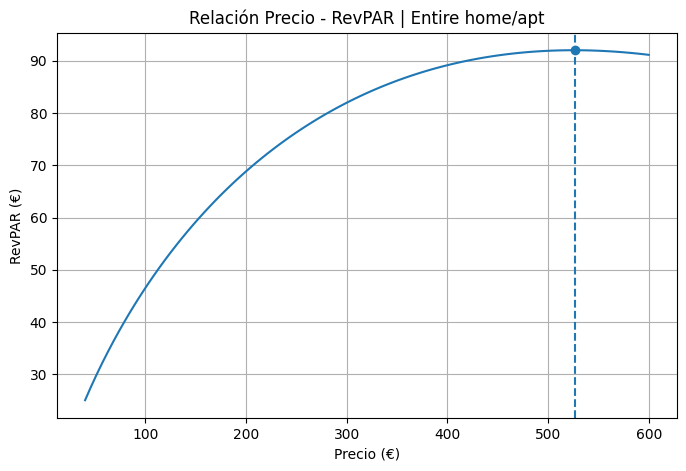

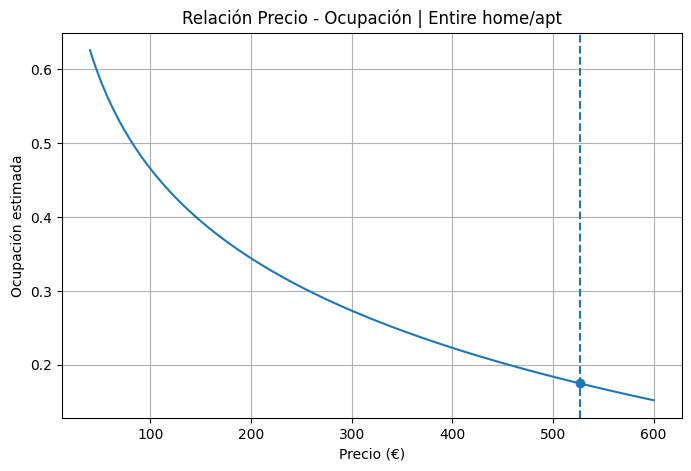

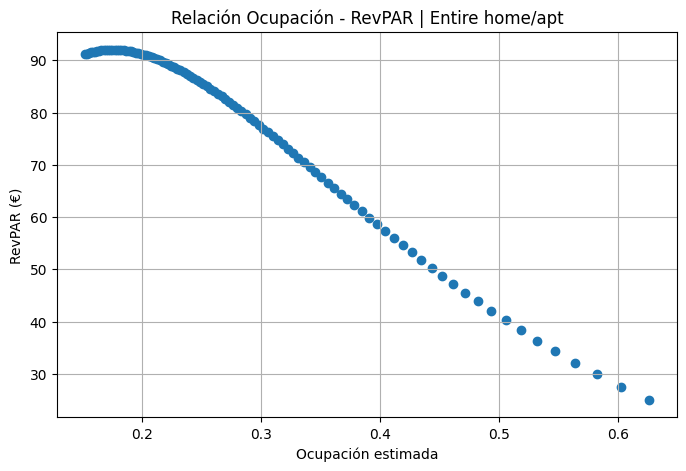

In [162]:
#8.4 SIMULACIÓN DE PRECIO ÓPTIMO (segmentado por entire home/apt):
#Filtrar solo viviendas completas:
entire = listings[listings["room_type"] == "Entire home/apt"].copy()

# Asegurarme de que hay occupancy_rate:
if "occupancy_rate" not in entire.columns:
    entire["occupancy_rate"] = entire["estimated_occupancy_l365d"] / 365
    
#Evitar problemas con log(0):
entire = entire[entire["price"] > 0].copy()

# Creación variable logarítmica del precio:
entire["log_price"] = np.log(entire["price"])

#Revisar nulos en variables del modelo segmentado:
print(entire[[
    "occupancy_rate", "log_price", "accommodates", "bedrooms",
    "amenities_count", "has_wifi", "bathrooms_missing",
    "neighbourhood_cleansed", "review_scores_rating", "host_is_superhost"
]].isna().sum())

#Crear base específica del modelo segmentado:
entire_model_data = entire[[
    "occupancy_rate", "log_price", "price", "accommodates", "bedrooms",
    "amenities_count", "has_wifi", "bathrooms_missing",
    "neighbourhood_cleansed", "review_scores_rating", "host_is_superhost"
]].dropna().copy()

#A)MODELO DE OCUPACIÓN SEGMENTADO:
model_occ_entire_log = smf.ols(
    formula="""
    occupancy_rate ~ log_price +
                     accommodates + bedrooms +
                     amenities_count + has_wifi +
                     bathrooms_missing +
                     C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data= entire_model_data
).fit()
#Métricas del modelo de ocupación segmentado:
y_true_entire = entire_model_data["occupancy_rate"]
y_pred_entire = model_occ_entire_log.fittedvalues

rmse_entire = np.sqrt(mean_squared_error(y_true_entire, y_pred_entire))
mae_entire = mean_absolute_error(y_true_entire, y_pred_entire)

print("RMSE ocupación entire home/apt:", rmse_entire)
print("MAE ocupación entire home/apt:", mae_entire)
print(model_occ_entire_log.summary())
 
#B)SIMULACIÓN DE RANGOS DE PRECIOS:
price_range = np.linspace(40, 600, 100)


# C)CREACIÓN DE UN AIRBNB REPRESENTATIVO COMO BASE:
mean_values = entire_model_data.mean(numeric_only=True)
base = entire_model_data.iloc[0:1].copy()

#Sustituir las variables numéricas por la media:
for col in mean_values.index:
    if col in base.columns:
        base[col] = mean_values[col]

#Fijar por valores categóricos válidos:
base["room_type"] = "Entire home/apt"
base["neighbourhood_cleansed"] = entire["neighbourhood_cleansed"].mode()[0]


#D)SIMULACIÓN:
results = []
for p in price_range:
    base["price"] = p
    base["log_price"] = np.log(p)

    pred_occ = model_occ_entire_log.predict(base).iloc[0]

#Limitar al rango lógico [0,1]
    pred_occ = max(0, min(1, pred_occ))

    revpar = p * pred_occ

    results.append((p, pred_occ, revpar))

#Convertir a dataframe:
results_df_entire_log = pd.DataFrame(results, columns=["price", "occupancy", "revpar"])


#E)ENCONTRAR PRECIO ÓPTIMO:
optimal_entire_log = results_df_entire_log.loc[results_df_entire_log["revpar"].idxmax()]

print("RESULTADO FINAL DE ENTIRE HOME/APT, MODELO LOG")
print(f"Precio óptimo: {optimal_entire_log['price']:.2f} €")
print(f"Ocupación estimada: {optimal_entire_log['occupancy']:.3f}")
print(f"RevPAR máximo: {optimal_entire_log['revpar']:.2f} €")


#F)VISUALIZACIÓN DE RESULTADOS:
#RevPAR vs Precio:
plt.figure(figsize=(8,5))
plt.plot(results_df_entire_log["price"], results_df_entire_log["revpar"])
plt.axvline(optimal_entire_log["price"], linestyle="--")
plt.scatter(optimal_entire_log["price"], optimal_entire_log["revpar"])
plt.xlabel("Precio (€)")
plt.ylabel("RevPAR (€)")
plt.title("Relación Precio - RevPAR | Entire home/apt")
plt.grid()
plt.show()

#Ocupación vs Precio:
plt.figure(figsize=(8,5))
plt.plot(results_df_entire_log["price"], results_df_entire_log["occupancy"])
plt.axvline(optimal_entire_log["price"], linestyle="--")
plt.scatter(optimal_entire_log["price"], optimal_entire_log["occupancy"])
plt.xlabel("Precio (€)")
plt.ylabel("Ocupación estimada")
plt.title("Relación Precio - Ocupación | Entire home/apt")
plt.grid()
plt.show()

#RevPAR vs Ocupación:
plt.figure(figsize=(8,5))
plt.scatter(results_df_entire_log["occupancy"], results_df_entire_log["revpar"])
plt.xlabel("Ocupación estimada")
plt.ylabel("RevPAR (€)")
plt.title("Relación Ocupación - RevPAR | Entire home/apt")
plt.grid()
plt.show()

#G)OUTPUT DEL MODELO:
results_df_entire_log.to_csv(
    '/Users/luciagonzalezdavila/Documents/4º/TFG/Nuevas BBDD/price_optimization_entire_log.csv',
    index=False
)





In [163]:
#SIMULACIÓN DE PRECIO ÓPTIMO (RevPAR)
#Instalación de los paquestes necesarios:
import matplotlib.pyplot as plt

# 1.DEFINIR RANGO DE PRECIOS
price_range = np.linspace(30, 300, 50)

# 2.CREAR UN "AIRBNB REPRESENTATIVO"
#Usamos dataframe
mean_values = listings.mean(numeric_only=True)

#Cogemos una fila real (manteniendo así una estructura de variables categóricas)
base = listings.iloc[0:1].copy()

#Sustituimos variables numéricas por la media
for col in mean_values.index:
    if col in base.columns:
        base[col] = mean_values[col]
        
#Asegurarnos de que las categóricas tienen valores válidos
base['room_type'] = listings['room_type'].mode()[0]
base['neighbourhood_cleansed'] = listings['neighbourhood_cleansed'].mode()[0]

# 3. SIMULACIÓN
results = []

for p in price_range:
    base['price'] = p
    
    # Usamos TU modelo correcto
    pred_occ = model_occ.predict(base).iloc[0]
    
    # Limitar entre 0 y 1
    pred_occ = max(0, min(1, pred_occ))
    
    revpar = p * pred_occ
    
    results.append((p, pred_occ, revpar))
    
    
# 4. RESULTADOS
results_df = pd.DataFrame(results, columns=['price', 'occupancy', 'revpar'])

optimal = results_df.loc[results_df['revpar'].idxmax()]

print("=== RESULTADO ÓPTIMO ===")
print(f"Precio óptimo: {optimal['price']:.2f} €")
print(f"Ocupación estimada: {optimal['occupancy']:.3f}")
print(f"RevPAR máximo: {optimal['revpar']:.2f} €")


# 5. VISUALIZACIÓN
plt.figure()
plt.plot(results_df['price'], results_df['revpar'])
plt.xlabel('Precio (€)')
plt.ylabel('RevPAR (€)')
plt.title('Relación Precio - RevPAR')
plt.grid()
plt.show()


        

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'log_price' is not defined
    occupancy_rate ~ log_price + accommodates + bedrooms + amenities_count + has_wifi + bathrooms_missing +                      C(room_type) + C(neighbourhood_cleansed) +                      review_scores_rating + host_is_superhost
                     ^^^^^^^^^

In [ ]:
#NUEVO MODELO CON NO LINEALIDAD EN EL PRECIO: 
listings["price_sq"] = listings["price"]**2

model_occ_quad = smf.ols(
    formula="""
    occupancy_rate ~ price + price_sq + accommodates + bedrooms +
                     C(room_type) + C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data=listings
).fit()

print(model_occ_quad.summary())
#Centrar el precio en su media
listings["price_centered"] = listings["price"] - listings["price"].mean()

#Término cuadrático del precio centrado
listings["price_centered_sq"] = listings["price_centered"] ** 2
#ESTIAMCIÓN DEL MODELO: 
model_occ_quad_c = smf.ols(
    formula="""
    occupancy_rate ~ price_centered + price_centered_sq +
                     accommodates + bedrooms +
                     C(room_type) +
                     C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data=listings
).fit()

print(model_occ_quad_c.summary())


#Reestimar y simular por tipo de alojamiento



# 1. FILTRAR SOLO "ENTIRE HOME/APT"
entire = listings[listings["room_type"] == "Entire home/apt"].copy()

#Crear occupancy_rate si no existe ya en este dataframe
if "occupancy_rate" not in entire.columns:
    entire["occupancy_rate"] = entire["estimated_occupancy_l365d"] / 365
    


# 2. CENTRAR EL PRECIO Y CREAR TÉRMINO CUADRÁTICO
entire["price_centered"] = entire["price"] - entire["price"].mean()
entire["price_centered_sq"] = entire["price_centered"] ** 2


# 3. MODELO DE OCUPACIÓN PARA ENTIRE HOME/APT
#Carga de paquetes:
import statsmodels.formula.api as smf
#Creación del modelo:
model_occ_entire_quad = smf.ols(
    formula="""
    occupancy_rate ~ price_centered + price_centered_sq +
                     accommodates + bedrooms +
                     C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data=entire
).fit()

print(model_occ_entire_quad.summary())

# 4. SIMULACIÓN DE REVPAR PARA ENTIRE HOME/APT
import matplotlib.pyplot as plt

#Rango de precios a simular
price_range = np.linspace(40, 400, 60)

#Creación de un "Airbnb representativo" dentro del segmento Entire home/apt
mean_values = entire.mean(numeric_only=True)

#Cogemos una fila real para mantener la estructura correcta
base = entire.iloc[0:1].copy()

#Sustituimos las variables numéricas por sus valores medios
for col in mean_values.index:
    if col in base.columns:
        base[col] = mean_values[col]

#Aseguramos valores válidos para las categóricas
base["room_type"] = "Entire home/apt"
base["neighbourhood_cleansed"] = entire["neighbourhood_cleansed"].mode()[0]

#Guardamos la media del precio para recalcular price_centered
price_mean_entire = entire["price"].mean()

results = []
for p in price_range:
    #Actualizamos precio
    base["price"] = p
    
    #Recalculamos precio centrado y su cuadrado
    base["price_centered"] = p - price_mean_entire
    base["price_centered_sq"] = (p - price_mean_entire) ** 2
    
    #Predecimos ocupación
    pred_occ = model_occ_entire_quad.predict(base).iloc[0]
    
    #Limitamos la ocupación al rango lógico [0, 1]
    pred_occ = max(0, min(1, pred_occ))
    
    #Calculamos RevPAR
    revpar = p * pred_occ
    
    #Guardamos
    results.append((p, pred_occ, revpar))

#Convertimos a DataFrame
results_df_entire = pd.DataFrame(results, columns=["price", "occupancy", "revpar"])

#Encontramos el punto óptimo
optimal_entire = results_df_entire.loc[results_df_entire["revpar"].idxmax()]

print("=== RESULTADO ÓPTIMO | ENTIRE HOME/APT ===")
print(f"Precio óptimo: {optimal_entire['price']:.2f} €")
print(f"Ocupación estimada: {optimal_entire['occupancy']:.3f}")
print(f"RevPAR máximo: {optimal_entire['revpar']:.2f} €")




# 5. GRÁFICO REVPAR VS PRECIO
plt.figure(figsize=(8,5))
plt.plot(results_df_entire["price"], results_df_entire["revpar"])
plt.axvline(optimal_entire["price"], linestyle="--")
plt.xlabel("Precio (€)")
plt.ylabel("RevPAR (€)")
plt.title("Relación Precio - RevPAR | Entire home/apt")
plt.grid()
plt.show()



# 6. GRÁFICO OCUPACIÓN VS PRECIO
plt.figure(figsize=(8,5))
plt.plot(results_df_entire["price"], results_df_entire["occupancy"])
plt.axvline(optimal_entire["price"], linestyle="--")
plt.xlabel("Precio (€)")
plt.ylabel("Ocupación estimada")
plt.title("Relación Precio - Ocupación | Entire home/apt")
plt.grid()
plt.show()


In [ ]:
#Opción A. Probar una especificación logarítmica en precio
# ============================================
# 1. ASEGURAR QUE TENEMOS EL MODELO LOG
# ============================================

import matplotlib.pyplot as plt

# Crear variable log_price si no existe
entire["log_price"] = np.log(entire["price"])


# Modelo logarítmico (por si quieres re-ejecutarlo limpio)
import statsmodels.formula.api as smf

model_occ_entire_log = smf.ols(
    formula="""
    occupancy_rate ~ log_price +
                     accommodates + bedrooms +
                     C(neighbourhood_cleansed) +
                     review_scores_rating + host_is_superhost
    """,
    data=entire
).fit()

print(model_occ_entire_log.summary())


# ============================================
# 2. CREAR RANGO DE PRECIOS
# ============================================

price_range = np.linspace(40, 400, 80)


# ============================================
# 3. CREAR AIRBNB REPRESENTATIVO
# ============================================

mean_values = entire.mean(numeric_only=True)

base = entire.iloc[0:1].copy()

# Sustituimos valores numéricos por medias
for col in mean_values.index:
    if col in base.columns:
        base[col] = mean_values[col]

# Fijamos categóricas coherentes
base["room_type"] = "Entire home/apt"
base["neighbourhood_cleansed"] = entire["neighbourhood_cleansed"].mode()[0]


# ============================================
# 4. SIMULACIÓN
# ============================================

results = []

for p in price_range:
    
    # Actualizar precio
    base["price"] = p
    
    # MUY IMPORTANTE: usar log
    base["log_price"] = np.log(p)
    
    # Predecir ocupación
    pred_occ = model_occ_entire_log.predict(base).iloc[0]
    
    # Limitar a rango lógico
    pred_occ = max(0, min(1, pred_occ))
    
    # Calcular RevPAR
    revpar = p * pred_occ
    
    results.append((p, pred_occ, revpar))


# Convertir a DataFrame
results_df_log = pd.DataFrame(results, columns=["price", "occupancy", "revpar"])


# ============================================
# 5. ENCONTRAR PRECIO ÓPTIMO
# ============================================

optimal_log = results_df_log.loc[results_df_log["revpar"].idxmax()]

print("=== RESULTADO FINAL (MODELO LOG) ===")
print(f"Precio óptimo: {optimal_log['price']:.2f} €")
print(f"Ocupación estimada: {optimal_log['occupancy']:.3f}")
print(f"RevPAR máximo: {optimal_log['revpar']:.2f} €")


# ============================================
# 6. GRÁFICO REVPAR
# ============================================

plt.figure(figsize=(8,5))
plt.plot(results_df_log["price"], results_df_log["revpar"])
plt.axvline(optimal_log["price"], linestyle="--")
plt.xlabel("Precio (€)")
plt.ylabel("RevPAR (€)")
plt.title("Relación Precio - RevPAR (modelo log)")
plt.grid()
plt.show()


# ============================================
# 7. GRÁFICO OCUPACIÓN
# ============================================

plt.figure(figsize=(8,5))
plt.plot(results_df_log["price"], results_df_log["occupancy"])
plt.axvline(optimal_log["price"], linestyle="--")
plt.xlabel("Precio (€)")
plt.ylabel("Ocupación estimada")
plt.title("Relación Precio - Ocupación (modelo log)")
plt.grid()
plt.show()
